In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (14,7)
plt.rcParams["font.size"] = 12

In [2]:
DATA_DIR = Path.home() / "b200_dynamic_range_max_pulses"

RAW_CSV = DATA_DIR / "dynamic_range_max_raw_measurements.csv"
POINTS_CSV = DATA_DIR / "dynamic_range_max_aggregated_points.csv"
SUMMARY_CSV = DATA_DIR / "dynamic_range_max_summary.csv"

raw_df = pd.read_csv(RAW_CSV)
points_df = pd.read_csv(POINTS_CSV)
summary_df = pd.read_csv(SUMMARY_CSV)

In [3]:
print(raw_df.shape)
print(points_df.shape)
print(summary_df.shape)

display(points_df.head())
display(summary_df.head())

(72100, 20)
(6100, 19)
(100, 15)


,frequency_hz,frequency_mhz,gain_db,input_rx2_dbm,generator_dbm,attenuation_db,max_dbfs,robust_dbfs,median_dbfs,noise_max_dbfs,noise_robust_dbfs,median_max_excess_db,median_robust_excess_db,detection_probability,peak_amplitude,clipping_fraction,predicted_max_dbfs,compression_db,linear
0,100000000.0,100.0,0.0,-80.0,-20.0,60.0,-59.927779,-61.554137,-72.717127,-59.816462,-61.643256,-0.111317,0.089118,0.0,0.001125,0.0,-80.405106,-20.477327,False
1,100000000.0,100.0,0.0,-79.0,-19.0,60.0,-59.821435,-61.470284,-72.682821,-59.816462,-61.643256,-0.004972,0.172972,0.0,0.001139,0.0,-79.485560,-19.664125,False
2,100000000.0,100.0,0.0,-78.0,-18.0,60.0,-60.179688,-61.452745,-72.585704,-59.816462,-61.643256,-0.363225,0.190510,0.0,0.001045,0.0,-78.566013,-18.386325,False
3,100000000.0,100.0,0.0,-77.0,-17.0,60.0,-59.813460,-61.270151,-72.518320,-59.816462,-61.643256,0.003002,0.373104,0.0,0.001132,0.0,-77.646466,-17.833006,False
4,100000000.0,100.0,0.0,-76.0,-16.0,60.0,-59.661984,-61.228044,-72.365812,-59.816462,-61.643256,0.154478,0.415212,0.0,0.001130,0.0,-76.726920,-17.064936,False


,frequency_hz,frequency_mhz,gain_db,rx2_min_tested_dbm,rx2_max_tested_dbm,noise_max_dbfs,noise_robust_dbfs,minimum_detectable_dbm,pmin_status,maximum_linear_dbm,pmax_status,dynamic_range_db,linear_fit_slope,linear_fit_intercept,number_of_input_points
0,100000000.0,100.0,0.0,-80.0,-20.0,-60.104687,-61.668926,-53.0,mesure_valide,-20.0,limite_haute_du_banc,33.0,0.919547,-6.841378,61
1,100000000.0,100.0,20.0,-80.0,-20.0,-55.618122,-57.088606,-68.0,mesure_valide,-20.0,limite_haute_du_banc,48.0,0.944887,11.117440,61
2,100000000.0,100.0,40.0,-80.0,-20.0,-50.458446,-51.907447,-80.0,limite_basse_du_banc,-43.0,mesure_valide,37.0,0.873323,28.440284,61
3,100000000.0,100.0,60.0,-80.0,-20.0,-34.866095,-36.134553,-80.0,limite_basse_du_banc,-54.0,mesure_valide,26.0,0.875596,45.541532,61
4,100000000.0,100.0,76.0,-80.0,-20.0,-21.644016,-23.241550,-80.0,limite_basse_du_banc,NaN,aucun_point_lineaire,NaN,NaN,NaN,61


In [11]:
GAIN = 40

gain_points = points_df[
    points_df["gain_db"] == GAIN
].copy()

gain_summary = summary_df[
    summary_df["gain_db"] == GAIN
].copy()

gain_points = gain_points.sort_values(
    ["input_rx2_dbm","frequency_mhz"]
)

gain_summary = gain_summary.sort_values(
    "frequency_mhz"
)

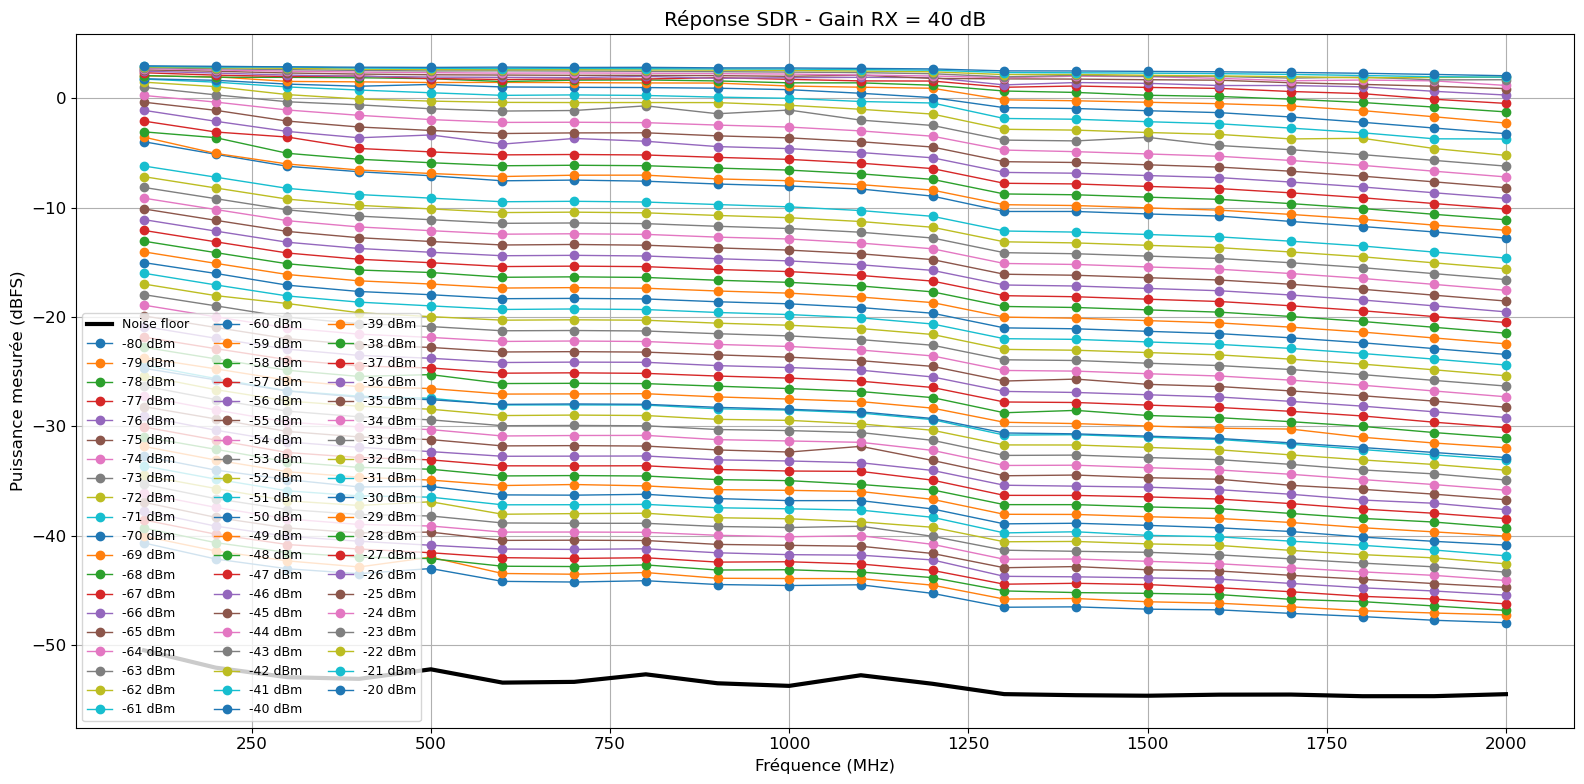

In [12]:
plt.figure(figsize=(16,8))

##########################################
# Noise floor
##########################################

plt.plot(
    gain_summary["frequency_mhz"],
    gain_summary["noise_max_dbfs"],
    color="black",
    linewidth=3,
    label="Noise floor"
)

##########################################
# Toutes les puissances injectées
##########################################

levels = sorted(
    gain_points["input_rx2_dbm"].unique()
)

for level in levels:

    df = gain_points[
        gain_points["input_rx2_dbm"] == level
    ]

    plt.plot(
        df["frequency_mhz"],
        df["max_dbfs"],
        marker="o",
        linewidth=1,
        markersize=6,
        label=f"{level:.0f} dBm"
    )

plt.title(f"Réponse SDR - Gain RX = {GAIN} dB")

plt.xlabel("Fréquence (MHz)")
plt.ylabel("Puissance mesurée (dBFS)")

plt.grid(True)

plt.legend(
    ncol=3,
    fontsize=9
)

plt.tight_layout()
plt.show()

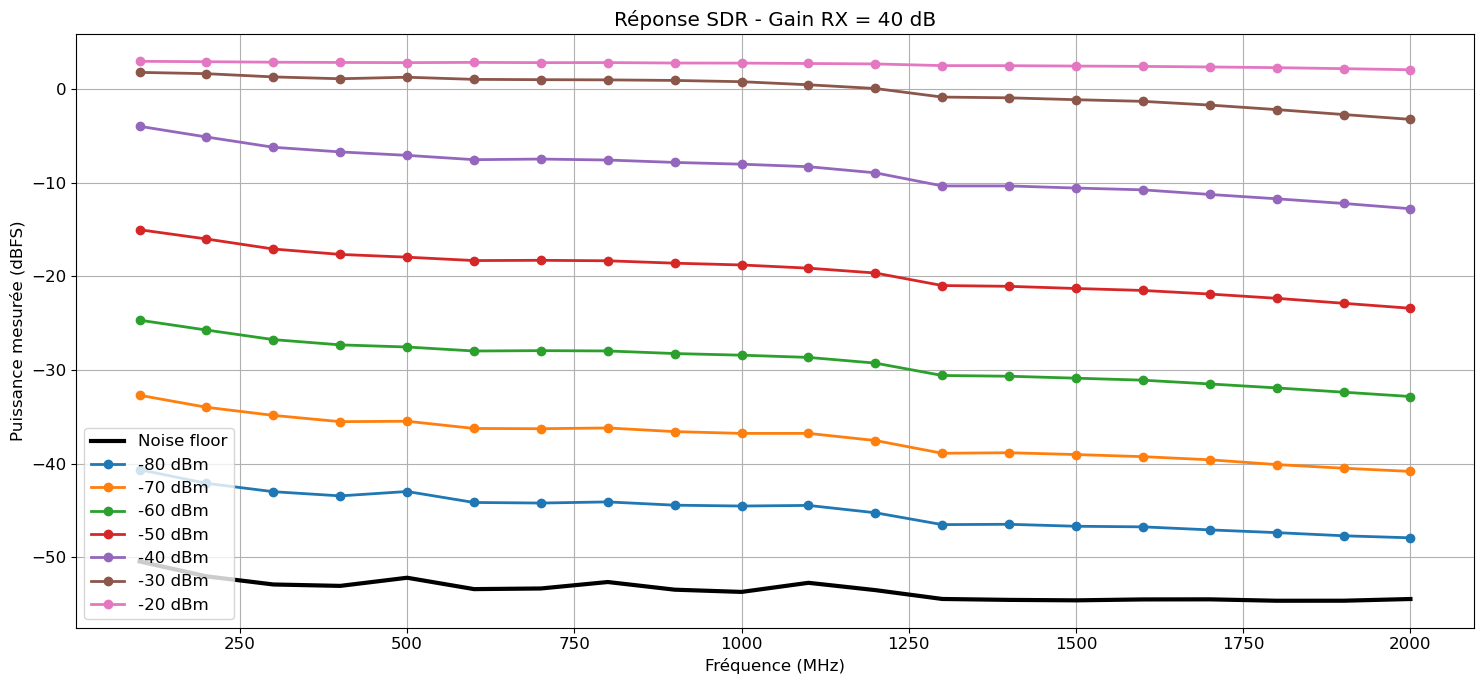

In [13]:
DISPLAY_LEVELS = [
    -80,
    -70,
    -60,
    -50,
    -40,
    -30,
    -20
]

plt.figure(figsize=(15,7))

plt.plot(
    gain_summary["frequency_mhz"],
    gain_summary["noise_max_dbfs"],
    color="black",
    linewidth=3,
    label="Noise floor"
)

for level in DISPLAY_LEVELS:

    df = gain_points[
        np.isclose(
            gain_points["input_rx2_dbm"],
            level
        )
    ]

    if len(df)==0:
        continue

    plt.plot(
        df["frequency_mhz"],
        df["max_dbfs"],
        marker="o",
        linewidth=2,
        label=f"{level} dBm"
    )

plt.title(f"Réponse SDR - Gain RX = {GAIN} dB")

plt.xlabel("Fréquence (MHz)")
plt.ylabel("Puissance mesurée (dBFS)")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [7]:
gain_summary[
[
    "frequency_mhz",
    "minimum_detectable_dbm",
    "maximum_linear_dbm",
    "dynamic_range_db"
]
]

,frequency_mhz,minimum_detectable_dbm,maximum_linear_dbm,dynamic_range_db
3,100.0,-80.0,-54.0,26.0
8,200.0,-80.0,-54.0,26.0
13,300.0,-80.0,-54.0,26.0
18,400.0,-80.0,-54.0,26.0
23,500.0,-80.0,-54.0,26.0
28,600.0,-80.0,-53.0,27.0
33,700.0,-80.0,-53.0,27.0
38,800.0,-80.0,-53.0,27.0
43,900.0,-80.0,-53.0,27.0
48,1000.0,-80.0,-53.0,27.0
